In [18]:
import pandas as pd
import numpy as np 
from scipy import stats
import matplotlib.pyplot as plt 
import seaborn as sns

Создано 15 точек в 3 сгущениях:
Первые 5 точек (сгущение 1):

Запущена агломеративная кластеризация
Начинаем с 90 отдельных кластеров
Всего шагов объединения: 89
Шаг 1: объединяются кластеры
  Кластер 72 (1 точек) + Кластер 87 (1 точек)
  Расстояние: 0.0242
  Новый кластер 90: 2 точек

Шаг 2: объединяются кластеры
  Кластер 6 (1 точек) + Кластер 18 (1 точек)
  Расстояние: 0.0285
  Новый кластер 91: 2 точек

Шаг 3: объединяются кластеры
  Кластер 40 (1 точек) + Кластер 57 (1 точек)
  Расстояние: 0.0310
  Новый кластер 92: 2 точек

Шаг 4: объединяются кластеры
  Кластер 52 (1 точек) + Кластер 92 (2 точек)
  Расстояние: 0.0375
  Новый кластер 93: 3 точек

Шаг 5: объединяются кластеры
  Кластер 38 (1 точек) + Кластер 49 (1 точек)
  Расстояние: 0.0521
  Новый кластер 94: 2 точек

Шаг 6: объединяются кластеры
  Кластер 65 (1 точек) + Кластер 71 (1 точек)
  Расстояние: 0.0646
  Новый кластер 95: 2 точек

Шаг 7: объединяются кластеры
  Кластер 2 (1 точек) + Кластер 21 (1 точек)
  Расстояние: 0

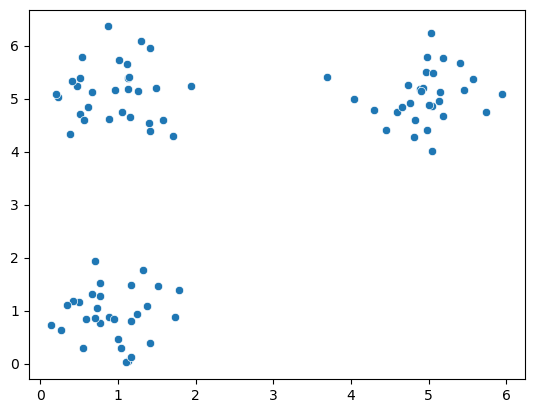

In [19]:
import numpy as np
from scipy.cluster.hierarchy import linkage
from sklearn.metrics import silhouette_score

# Создаем 3 сгущения точек на плоскости
np.random.seed(42)

points1 = np.random.randn(30, 2) * 0.5 + [1, 1]

points2 = np.random.randn(30, 2) * 0.5 + [5, 5]

points3 = np.random.randn(30, 2) * 0.5 + [1, 5]

X = np.vstack([points1, points2, points3]) 

sns.scatterplot(x = X[:, 0], y = X[:, 1])

print("Создано 15 точек в 3 сгущениях:")
print("Первые 5 точек (сгущение 1):")

# Применяем агломеративный алгоритм
Z = linkage(X, method='single')

print(f"\nЗапущена агломеративная кластеризация")
print(f"Начинаем с {len(X)} отдельных кластеров")
print(f"Всего шагов объединения: {len(Z)}")


silhouettes = []
# каждая точка - отдельный кластер
clusters = [[i] for i in range(len(X))]  # список списков точек
labels = np.arange(len(X))
n_clusters_current = len(X)

# Проходим по всем объединениям в Z
for step in range(len(Z)):
    # Извлекаем информацию из строки Z
    idx1 = int(Z[step, 0])
    idx2 = int(Z[step, 1])
    distance = Z[step, 2]
    new_size = int(Z[step, 3])
    
    if idx1 < len(X):
        cluster1 = clusters[idx1]
    else:
        cluster1 = clusters[idx1]
    
    if idx2 < len(X):
        cluster2 = clusters[idx2]
    else:
        cluster2 = clusters[idx2]
    
    # Создаем новый кластер
    new_cluster = cluster1 + cluster2
    clusters.append(new_cluster)

    for el in new_cluster:
        labels[el] = len(clusters) - 1

    n_clusters_current -= 1  # уменьшаем количество кластеров на 1
    if n_clusters_current > 1:  # силуэт можно вычислить только если кластеров > 1
        sil_score = silhouette_score(X, labels)
        silhouettes.append(sil_score)
    else:
        silhouettes.append(None) 
    
    print(f"Шаг {step+1}: объединяются кластеры")
    print(f"  Кластер {idx1} ({len(cluster1)} точек) + Кластер {idx2} ({len(cluster2)} точек)")
    print(f"  Расстояние: {distance:.4f}")
    print(f"  Новый кластер {len(X)+step}: {len(new_cluster)} точек")
    print()

# 4. Результат

print(f"РЕЗУЛЬТАТ: Все {len(X)} точек объединены в один кластер")

3.0 87.0 Оптимальные колво кластеров и шаг


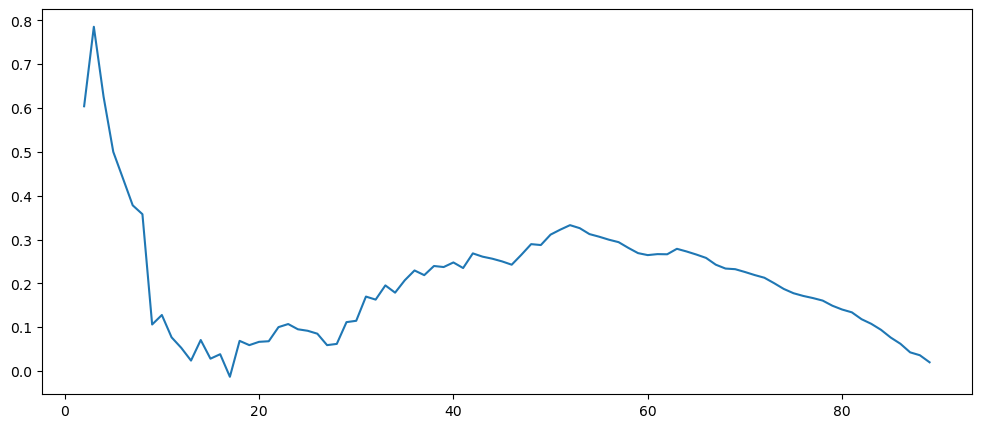

In [20]:
table_data = []
for i, sil in enumerate(silhouettes):
    n_clusters = len(X) - i - 1  # Количество кластеров на этом шаге
    table_data.append([i+1, n_clusters, sil])

df_sil = pd.DataFrame(table_data, columns=['Шаг', 'Количество кластеров', 'Silhouette'])
best_n_clusters = df_sil.sort_values('Silhouette', ascending= False).iloc[0]['Количество кластеров']
best_step = df_sil.sort_values('Silhouette', ascending= False).iloc[0]['Шаг'] 
print(best_n_clusters, best_step, 'Оптимальные колво кластеров и шаг')

plt.figure(figsize=(12, 5))
plt.plot(df_sil['Количество кластеров'], df_sil['Silhouette'] )


Запущена агломеративная кластеризация
Начинаем с 90 отдельных кластеров
Всего шагов объединения: 89


<Axes: xlabel='long', ylabel='latt'>

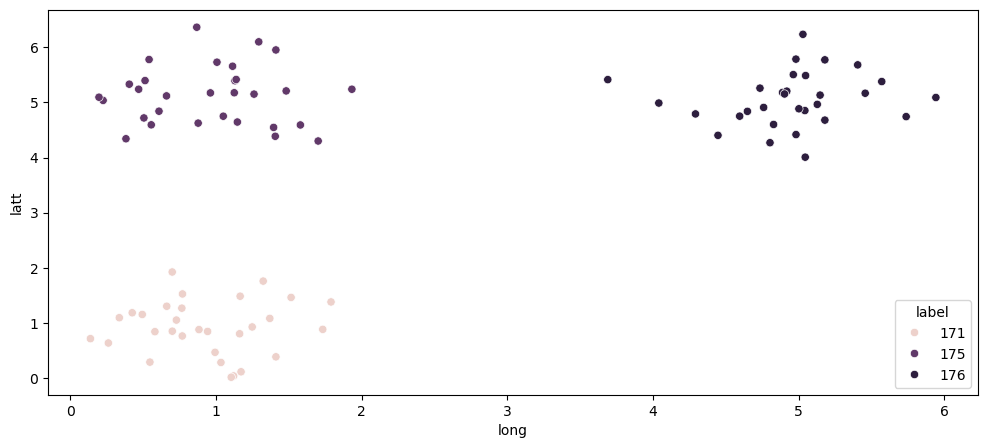

In [21]:
Z = linkage(X, method='single')

print(f"\nЗапущена агломеративная кластеризация")
print(f"Начинаем с {len(X)} отдельных кластеров")
print(f"Всего шагов объединения: {len(Z)}")


silhouettes = []
# каждая точка - отдельный кластер
clusters = [[i] for i in range(len(X))]  # список списков точек
labels = np.arange(len(X))
n_clusters_current = len(X)

# Проходим по всем объединениям в Z
for step in range(87):
    # Извлекаем информацию из строки Z
    idx1 = int(Z[step, 0])
    idx2 = int(Z[step, 1])
    distance = Z[step, 2]
    new_size = int(Z[step, 3])
    
    if idx1 < len(X):
        cluster1 = clusters[idx1]
    else:
        cluster1 = clusters[idx1]
    
    if idx2 < len(X):
        cluster2 = clusters[idx2]
    else:
        cluster2 = clusters[idx2]
    
    # Создаем новый кластер
    new_cluster = cluster1 + cluster2
    clusters.append(new_cluster)

    for el in new_cluster:
        labels[el] = len(clusters) - 1

plt.figure(figsize=(12, 5))
coordinates = pd.DataFrame(X, columns = ['long', 'latt'])
coordinates['label'] = labels
sns.scatterplot(data = coordinates, x = 'long', y = 'latt', hue= 'label')

<Axes: >

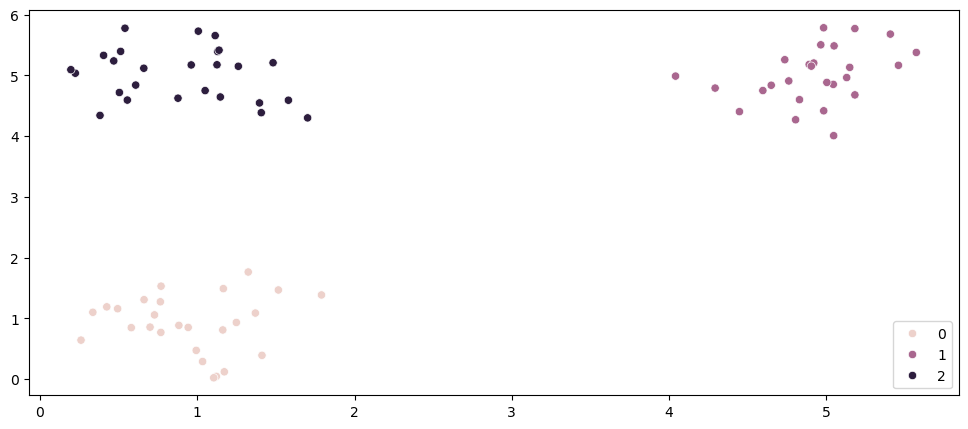

In [29]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps = 0.4, min_samples= 4 )
labels = dbscan.fit_predict(X)
labels
X_without_extra, labels_without_extra = X[labels != -1], labels[labels != -1]
len(X), len(X_without_extra)

plt.figure(figsize=(12, 5))
sns.scatterplot(x = X_without_extra[:, 0], y = X_without_extra[:, 1], hue = labels_without_extra)